In [ ]:
import numpy as np
import time
import pandas as pd
from collections import deque


tol = 1e-5
eta = 0.1
delta_max = 1.25

In [ ]:

from bfgslimemna import rcBFGSLiMem
from dixma import dixmaana, dixmaana_grad




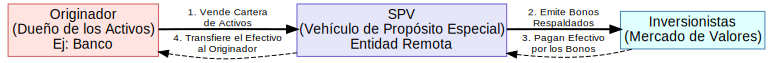

In [ ]:
# Primero necesitas instalar la librería en tu terminal:
# pip install graphviz

from graphviz import Digraph

# Crear el objeto del diagrama
dot = Digraph('Bursatilizacion', comment='Estructura de Bursatilización')

# --- Configuración General ---
dot.attr(rankdir='LR') # De Izquierda a Derecha
dot.attr('node', shape='rect', style='filled', fontname='Helvetica')
dot.attr('edge', fontname='Helvetica', fontsize='10')

# --- Definición de Nodos (Las Cajas) ---
# Originador
dot.node('A', 'Originador\n(Dueño de los Activos)\nEj: Banco',
         fillcolor='#FFE4E1', color='#CD5C5C')

# SPV
dot.node('B', 'SPV\n(Vehículo de Propósito Especial)\nEntidad Remota',
         fillcolor='#E6E6FA', color='#6A5ACD')

# Inversionistas
dot.node('C', 'Inversionistas\n(Mercado de Valores)',
         fillcolor='#E0FFFF', color='#4682B4')

# --- Definición de Relaciones (Las Flechas) ---

# Fase 1: Venta de activos
dot.edge('A', 'B', label='1. Vende Cartera\nde Activos', penwidth='2')

# Fase 2: Emisión de bonos
dot.edge('B', 'C', label='2. Emite Bonos\nRespaldados', penwidth='2')

# Fase 3: Flujo de dinero (Usamos dir='back' para invertir la flecha visualmente)
dot.edge('B', 'C', label='3. Pagan Efectivo\npor los Bonos', style='dashed', dir='back')
dot.edge('A', 'B', label='4. Transfiere el Efectivo\nal Originador', style='dashed', dir='back')

# --- Visualización ---
# Esto generará un archivo PDF y lo abrirá automáticamente
dot.render('diagrama_bursatilizacion', view=True, format='png')

# Si estás en Jupyter Notebook / Colab, simplemente escribe 'dot' en la última línea
dot

In [ ]:

def simu_rcBFGSLiMem():
    """Simulation of the rcBFGSLiMem method on the DIXMAANA function."""
    dimensiones = [240, 960]
    valores_m = [1, 3, 5, 17, 29]
    itmax = 200

    for n in dimensiones:
        x0 = np.ones(n)
        resultados = []

        for m in valores_m:
            f_wrapper = lambda x: (dixmaana(x), apGrad(dixmaana, x))
            x_opt, its, grad_norm_inf, f_val, tiempo = rcBFGSLiMem(f_wrapper, x0, itmax, m)
            resultados.append([m, its, grad_norm_inf, f_val, tiempo])

        print(f"\n=== rcBFGSLiMem para n = {n} ===")
        print(" m  │ iteraciones │ ∥∇f∥inf    │ f(x)        │ t (s)")
        print("────┼────────────┼──────────┼─────────────┼─────────")
        for row in resultados:
            print(f"{row[0]:3d} │ {row[1]:12d} │ {row[2]:<9.2e} │ {row[3]:<11.2e} │ {row[4]:<7.2f}")


if __name__ == "__main__":
    simulate_rcBFGSLiMem()




=== rcBFGSLiMem para n = 240 ===
 m  │ iteraciones │ ∥∇f∥∞    │ f(x)        │ t (s)
────┼────────────┼──────────┼─────────────┼─────────
  1 │          200 │ 3.42e+00  │ -1.44e+01   │ 5.32   
  3 │          200 │ 1.60e+01  │ -1.80e+01   │ 6.45   
  5 │          200 │ 1.48e+01  │ -2.10e+01   │ 5.07   
 17 │          200 │ 9.76e+00  │ -1.69e+01   │ 5.93   
 29 │          200 │ 5.02e+00  │ -1.23e+01   │ 4.87   

=== rcBFGSLiMem para n = 960 ===
 m  │ iteraciones │ ∥∇f∥∞    │ f(x)        │ t (s)
────┼────────────┼──────────┼─────────────┼─────────
  1 │          200 │ 5.31e-01  │ -2.26e+01   │ 29.94  
  3 │          200 │ 4.48e-01  │ -2.25e+01   │ 30.99  
  5 │          200 │ 4.61e-01  │ -2.19e+01   │ 30.43  
 17 │          200 │ 7.81e-01  │ -2.36e+01   │ 31.01  
 29 │          200 │ 7.72e-01  │ -2.37e+01   │ 30.41  


In [ ]:
# restricciones
A= np.array()